In [ ]:
!pip install xgboost

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [3]:
from catboost import CatBoostRegressor

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from xgboost import XGBRegressor

import joblib

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("final_dataset.csv")

df.head()

,Date,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,...,RollingMin14,RollingMedian14,RollingMean30,RollingStd30,RollingMax30,RollingMin30,RollingMedian30,EMA7,EMA14,ExpandingMean
0,2024-01-03,1/3/2024,46,Casual Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,24.51,53.13,...,0.0,184.0,227.766667,168.273317,711.0,0.0,205.0,185.421979,201.499560,270.721311
1,2024-01-03,1/3/2024,50,Food Stall,Roti Canai,Breakfast,"flour, ghee, egg, water, curry",0.8,1.74,2.92,...,0.0,184.0,222.766667,165.523346,711.0,0.0,205.0,198.816484,206.500320,270.209677
2,2024-01-03,1/3/2024,40,Food Stall,Cendol,Dinner,"rice flour jelly, coconut milk, palm sugar, re...",2.0,3.75,8.38,...,0.0,148.0,218.566667,167.964012,711.0,0.0,203.0,165.112363,187.497968,266.936508
3,2024-01-03,1/3/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,9.08,13.76,...,0.0,184.0,221.133333,168.037503,711.0,0.0,229.0,189.584272,197.565966,266.875000
4,2024-01-03,1/3/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,1.62,1.73,...,0.0,184.0,242.566667,183.146010,711.0,0.0,238.5,310.438205,260.962958,273.123077


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

df.head()

,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,...,RollingMin14,RollingMedian14,RollingMean30,RollingStd30,RollingMax30,RollingMin30,RollingMedian30,EMA7,EMA14,ExpandingMean
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-03,1/3/2024,46,Casual Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,24.51,53.13,148,...,0.0,184.0,227.766667,168.273317,711.0,0.0,205.0,185.421979,201.499560,270.721311
2024-01-03,1/3/2024,8,Casual Dining,Kaya Toast Set,Breakfast,"white bread, kaya, butter, soft-boiled eggs",2.8,8.49,15.34,232,...,23.0,201.0,228.700000,164.151770,673.0,0.0,201.0,207.019147,213.749565,263.610390
2024-01-03,1/3/2024,46,Casual Dining,Cendol,Dinner,"rice flour jelly, coconut milk, palm sugar, re...",2.0,6.72,9.66,274,...,23.0,186.5,222.933333,167.045097,673.0,0.0,186.5,198.692196,210.941752,264.026316
2024-01-03,1/3/2024,44,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,12.65,14.06,192,...,23.0,186.5,223.566667,168.334372,673.0,0.0,186.5,193.786126,214.816040,265.932432
2024-01-03,1/3/2024,25,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,41.75,62.39,103,...,23.0,164.5,228.933333,169.852864,673.0,0.0,195.5,194.381501,218.326302,266.945205


In [13]:
# Lag Features
for lag in [1, 2, 3, 7, 14, 21, 28]:
    df[f"lag_{lag}"] = df["quantity_sold"].shift(lag)

# Rolling Mean
for window in [3, 7, 14, 30]:
    df[f"rolling_mean_{window}"] = (
        df["quantity_sold"]
        .shift(1)
        .rolling(window)
        .mean()
    )

# Rolling Std
for window in [7, 14]:
    df[f"rolling_std_{window}"] = (
        df["quantity_sold"]
        .shift(1)
        .rolling(window)
        .std()
    )

df = df.dropna()

In [14]:
target = "quantity_sold"

drop_columns = [
    "date",
    "quantity_sold",
    "dayName"
]

X = df.drop(columns=drop_columns)

y = df[target]

print(X.columns)

Index(['restaurant_id', 'restaurant_type', 'menu_item_name', 'meal_type',
       'key_ingredients_tags', 'typical_ingredient_cost',
       'observed_market_price', 'actual_selling_price', 'has_promotion',
       'special_event', 'weather_condition', 'year', 'month', 'quarter',
       'week', 'day', 'dayOfWeek', 'isWeekend', 'day_sin', 'day_cos',
       'month_sin', 'month_cos', 'week_sin', 'week_cos', 'IsWeekend',
       'IsHoliday', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Lag_14',
       'Lag_21', 'Lag_30', 'Lag_60', 'RollingMean7', 'RollingStd7',
       'RollingMax7', 'RollingMin7', 'RollingMedian7', 'RollingMean14',
       'RollingStd14', 'RollingMax14', 'RollingMin14', 'RollingMedian14',
       'RollingMean30', 'RollingStd30', 'RollingMax30', 'RollingMin30',
       'RollingMedian30', 'EMA7', 'EMA14', 'ExpandingMean', 'lag_1', 'lag_2',
       'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_3',
       'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rollin

In [15]:
# Keep chronological order
train_size = int(len(df) * 0.85)

X_train = X.iloc[:train_size].copy()
X_test = X.iloc[train_size:].copy()

y_train = y.iloc[:train_size].copy()
y_test = y.iloc[train_size:].copy()

print(X_train.shape, X_test.shape)

(8423, 66) (1487, 66)


In [16]:
full = pd.concat([X_train, X_test])

full = pd.get_dummies(full, drop_first=True)

X_train = full.iloc[:len(X_train)]
X_test = full.iloc[len(X_train):]

In [19]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

In [20]:
xgb = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=2500,

    learning_rate=0.01,

    max_depth=6,

    min_child_weight=2,

    gamma=0.2,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.5,

    reg_lambda=2,

    random_state=42,

    n_jobs=-1

)

In [21]:
print(df.shape)

(9910, 69)


In [22]:
from xgboost import XGBRegressor

best_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

best_model.fit(X_train, y_train)

prediction = best_model.predict(X_test)

from sklearn.metrics import r2_score

print("R² Score:", r2_score(y_test, prediction))

R² Score: 0.9193804264068604


In [23]:
cat = CatBoostRegressor(

    iterations=500,

    learning_rate=0.05,

    depth=6,

    random_seed=42,

    verbose=0

)

cat.fit(X_train,y_train)

cat_pred = cat.predict(X_test)

print("CatBoost")

print("MAE :",mean_absolute_error(y_test,cat_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,cat_pred)))

CatBoost
MAE : 39.81889440121167
RMSE : 60.037959129692936


In [24]:
model = best_model

In [25]:
# Model is already trained
prediction = model.predict(X_test)

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, prediction)

rmse = np.sqrt(mean_squared_error(y_test, prediction))

r2 = r2_score(y_test, prediction)

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R² Score :", round(r2,4))

print("Accuracy :", round(r2*100,2),"%")

MAE : 42.35
RMSE : 63.9
R² Score : 0.9194
Accuracy : 91.94 %


In [27]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(15)

,Feature,Importance
1,typical_ingredient_cost,0.130712
77,menu_item_name_Teh Tarik,0.123523
3,actual_selling_price,0.096386
4,has_promotion,0.095471
70,menu_item_name_Kaya Toast Set,0.061086
65,menu_item_name_Cendol,0.057352
88,"key_ingredients_tags_rice flour jelly, coconut...",0.032305
78,meal_type_Dinner,0.031813
45,EMA7,0.029034
32,RollingMax7,0.024680


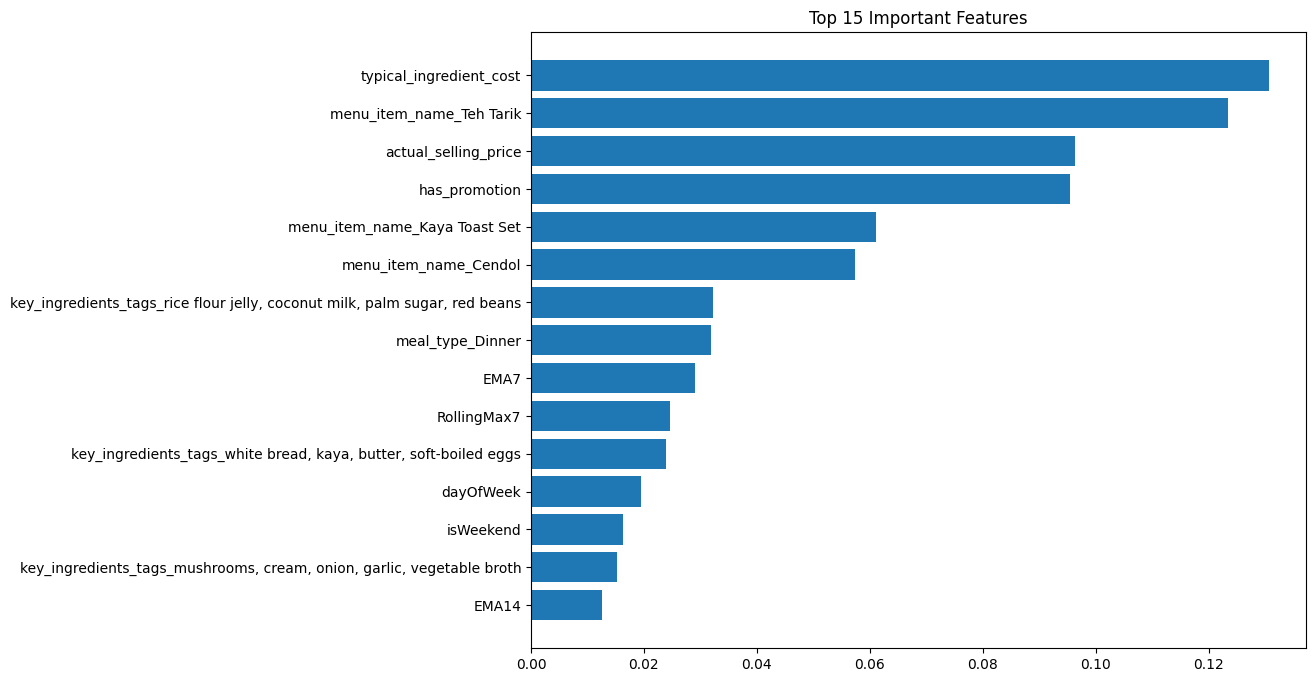

In [28]:
plt.figure(figsize=(10,8))

top = importance.head(15)

plt.barh(

    top["Feature"],

    top["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [29]:
joblib.dump(best_model, "restaurant_demand_model.pkl")

['restaurant_demand_model.pkl']